In [8]:
import os
project_root = r'c:\Projects\traffic-congestion-prediction'
os.chdir(project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             RocCurveDisplay,
                             f1_score,
                             recall_score,
                             precision_score)
import joblib
import time

print("Libraries imported successfully!")
print("Working directory:", os.getcwd())

Libraries imported successfully!
Working directory: c:\Projects\traffic-congestion-prediction


In [9]:
# Load preprocessed data
X_train = pd.read_csv('data/processed/X_train.csv')
X_val = pd.read_csv('data/processed/X_val.csv')
X_test = pd.read_csv('data/processed/X_test.csv')

y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_val = pd.read_csv('data/processed/y_val.csv').squeeze()
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()

class_weights = joblib.load('models/class_weights.pkl')

# XGBoost uses scale_pos_weight instead of class_weight dict
# = ratio of negative to positive samples
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Data loaded successfully!
X_train shape: (1297702, 12)
scale_pos_weight: 4.01


In [10]:
print("Training XGBoost baseline...")

start = time.time()

xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

training_time = time.time() - start
print(f"Training complete!")
print(f"Training time: {training_time:.1f} seconds")

# Validate
y_val_pred = xgb_model.predict(X_val)
y_val_prob = xgb_model.predict_proba(X_val)[:, 1]

print(f"\n=== XGBoost Baseline – Validation Results ===")
print(classification_report(y_val, y_val_pred,
      target_names=['No Congestion', 'Congestion']))
print(f"AUC-ROC: {roc_auc_score(y_val, y_val_prob):.4f}")

Training XGBoost baseline...
Training complete!
Training time: 2.1 seconds

=== XGBoost Baseline – Validation Results ===
               precision    recall  f1-score   support

No Congestion       0.96      0.92      0.94    236537
   Congestion       0.64      0.80      0.71     41542

     accuracy                           0.90    278079
    macro avg       0.80      0.86      0.83    278079
 weighted avg       0.92      0.90      0.91    278079

AUC-ROC: 0.9474


In [11]:
results = []

# Store baseline
results.append({
    'config': 'Baseline (100 trees)',
    'f1': f1_score(y_val, y_val_pred),
    'recall': recall_score(y_val, y_val_pred),
    'time': 2.1
})

configs = [
    {
        'name': 'Config 2 (200 trees, max_depth=6)',
        'params': {
            'n_estimators': 200,
            'max_depth': 6,
            'learning_rate': 0.1,
            'scale_pos_weight': scale_pos_weight,
            'random_state': 42,
            'n_jobs': -1,
            'eval_metric': 'logloss',
            'verbosity': 0
        }
    },
    {
        'name': 'Config 3 (200 trees, max_depth=8)',
        'params': {
            'n_estimators': 200,
            'max_depth': 8,
            'learning_rate': 0.1,
            'scale_pos_weight': scale_pos_weight,
            'random_state': 42,
            'n_jobs': -1,
            'eval_metric': 'logloss',
            'verbosity': 0
        }
    }
]

for config in configs:
    print(f"Training {config['name']}...")
    start = time.time()
    model = XGBClassifier(**config['params'])
    model.fit(X_train, y_train)
    t = time.time() - start
    
    pred = model.predict(X_val)
    f1 = f1_score(y_val, pred)
    recall = recall_score(y_val, pred)
    
    results.append({
        'config': config['name'],
        'f1': f1,
        'recall': recall,
        'time': t,
        'model': model
    })
    print(f"Done in {t:.1f}s – F1: {f1:.4f}, Recall: {recall:.4f}")

print(f"\n=== XGBoost Hyperparameter Tuning Results ===")
for r in results:
    print(f"\n{r['config']}")
    print(f"  F1:     {r['f1']:.4f}")
    print(f"  Recall: {r['recall']:.4f}")
    print(f"  Time:   {r['time']:.1f}s")

Training Config 2 (200 trees, max_depth=6)...
Done in 4.0s – F1: 0.7202, Recall: 0.8342
Training Config 3 (200 trees, max_depth=8)...
Done in 5.4s – F1: 0.7160, Recall: 0.8048

=== XGBoost Hyperparameter Tuning Results ===

Baseline (100 trees)
  F1:     0.7127
  Recall: 0.8049
  Time:   2.1s

Config 2 (200 trees, max_depth=6)
  F1:     0.7202
  Recall: 0.8342
  Time:   4.0s

Config 3 (200 trees, max_depth=8)
  F1:     0.7160
  Recall: 0.8048
  Time:   5.4s


In [12]:
print("=== Learning Rate Analysis ===")
print(f"{'LR':>6} {'F1':>8} {'Recall':>8} {'Time':>8}")
print("-" * 35)

lr_results = []
for lr in [0.01, 0.05, 0.1, 0.2, 0.3]:
    start = time.time()
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=lr,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    )
    model.fit(X_train, y_train)
    t = time.time() - start
    
    pred = model.predict(X_val)
    f1 = f1_score(y_val, pred)
    recall = recall_score(y_val, pred)
    
    lr_results.append({
        'lr': lr, 'f1': f1, 
        'recall': recall, 'time': t
    })
    print(f"{lr:>6.2f} {f1:>8.4f} {recall:>8.4f} {t:>7.1f}s")

best_lr = max(lr_results, key=lambda x: x['f1'])
print(f"\nBest learning rate: {best_lr['lr']}")
print(f"Best F1: {best_lr['f1']:.4f}")

=== Learning Rate Analysis ===
    LR       F1   Recall     Time
-----------------------------------
  0.01   0.7143   0.8924     6.9s
  0.05   0.7225   0.8427     6.8s
  0.10   0.7202   0.8342     5.9s
  0.20   0.7135   0.8120     6.5s
  0.30   0.7093   0.7234     5.3s

Best learning rate: 0.05
Best F1: 0.7225


In [13]:
print("Training XGBoost with early stopping...")
print("Using best lr=0.05, max_depth=6")

# Convert to DMatrix for early stopping
eval_set = [(X_val, y_val)]

xgb_best = XGBClassifier(
    n_estimators=500,       # max trees – early stopping
                            # will find optimal number
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0,
    early_stopping_rounds=10
)

start = time.time()
xgb_best.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False
)
t = time.time() - start

print(f"Training complete in {t:.1f}s")
print(f"Optimal number of trees: {xgb_best.best_iteration}")

y_val_pred_best = xgb_best.predict(X_val)
y_val_prob_best = xgb_best.predict_proba(X_val)[:, 1]

print(f"\n=== XGBoost with Early Stopping – Validation ===")
print(classification_report(y_val, y_val_pred_best,
      target_names=['No Congestion', 'Congestion']))
print(f"AUC-ROC: {roc_auc_score(y_val, y_val_prob_best):.4f}")

Training XGBoost with early stopping...
Using best lr=0.05, max_depth=6
Training complete in 8.1s
Optimal number of trees: 172

=== XGBoost with Early Stopping – Validation ===
               precision    recall  f1-score   support

No Congestion       0.97      0.91      0.94    236537
   Congestion       0.63      0.85      0.72     41542

     accuracy                           0.90    278079
    macro avg       0.80      0.88      0.83    278079
 weighted avg       0.92      0.90      0.91    278079

AUC-ROC: 0.9560


In [14]:
print("=== XGBoost Threshold Analysis ===")
print(f"{'Threshold':>10} {'Precision':>10} "
      f"{'Recall':>10} {'F1':>10}")
print("-" * 45)

best_f1 = 0
best_threshold = 0.5

for threshold in [0.3, 0.35, 0.4, 0.45, 0.5]:
    pred = (y_val_prob_best > threshold).astype(int)
    p = precision_score(y_val, pred)
    r = recall_score(y_val, pred)
    f1 = f1_score(y_val, pred)
    print(f"{threshold:>10.2f} {p:>10.4f} "
          f"{r:>10.4f} {f1:>10.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\nBest threshold: {best_threshold}")
print(f"Best F1: {best_f1:.4f}")

=== XGBoost Threshold Analysis ===
 Threshold  Precision     Recall         F1
---------------------------------------------
      0.30     0.5034     0.9306     0.6534
      0.35     0.5381     0.9114     0.6767
      0.40     0.5714     0.8916     0.6964
      0.45     0.6017     0.8702     0.7115
      0.50     0.6315     0.8473     0.7236

Best threshold: 0.5
Best F1: 0.7236


In [15]:
# Use best threshold 0.50 for XGBoost
BEST_THRESHOLD = 0.50

y_test_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]
y_test_pred_xgb = (y_test_prob_xgb > BEST_THRESHOLD).astype(int)

print("=== XGBoost Final Results (Test Set) ===")
print(f"Config: lr=0.05, max_depth=6, "
      f"early stopping (172 trees)")
print(f"Threshold: {BEST_THRESHOLD}")
print()
print(classification_report(y_test, y_test_pred_xgb,
      target_names=['No Congestion', 'Congestion']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_test_prob_xgb):.4f}")

=== XGBoost Final Results (Test Set) ===
Config: lr=0.05, max_depth=6, early stopping (172 trees)
Threshold: 0.5

               precision    recall  f1-score   support

No Congestion       0.97      0.92      0.94    232691
   Congestion       0.67      0.86      0.75     45388

     accuracy                           0.91    278079
    macro avg       0.82      0.89      0.85    278079
 weighted avg       0.92      0.91      0.91    278079

AUC-ROC: 0.9604


c:\Users\abood\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


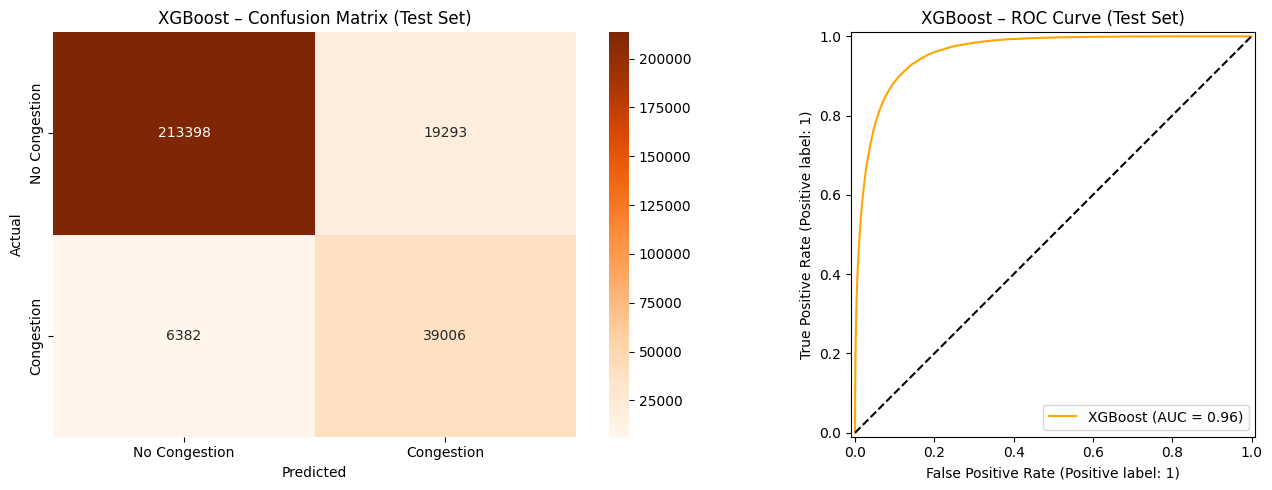

True Negatives:  213,398
False Positives: 19,293
False Negatives: 6,382
True Positives:  39,006


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Congestion', 'Congestion'],
            yticklabels=['No Congestion', 'Congestion'],
            ax=axes[0])
axes[0].set_title('XGBoost – Confusion Matrix (Test Set)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
RocCurveDisplay.from_predictions(
    y_test, y_test_prob_xgb,
    name='XGBoost',
    color='orange',
    ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('XGBoost – ROC Curve (Test Set)')

plt.tight_layout()
plt.savefig('results/figures/xgb_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

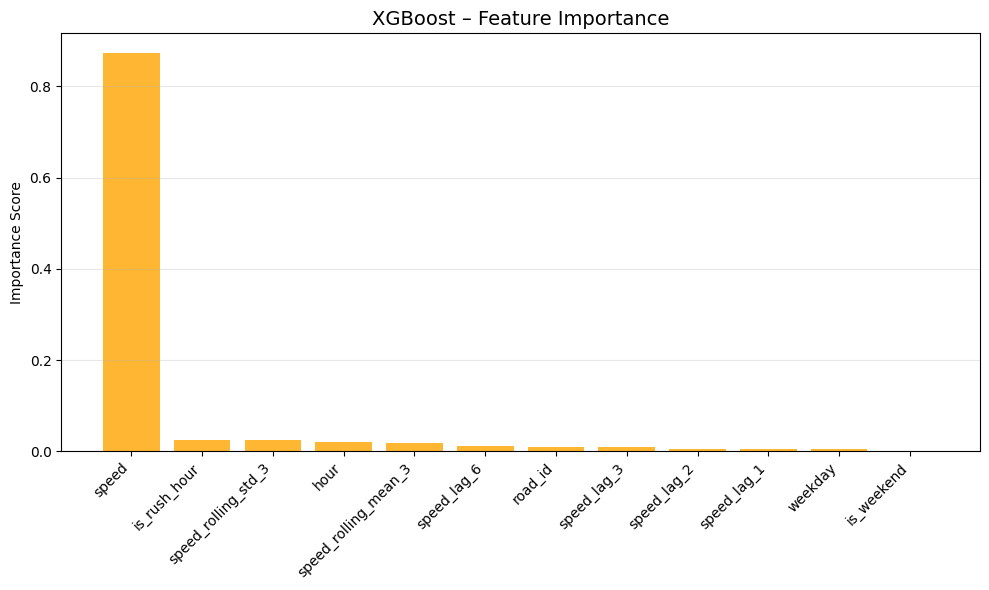

Feature importances:
  speed                    : 0.8727
  is_rush_hour             : 0.0248
  speed_rolling_std_3      : 0.0238
  hour                     : 0.0193
  speed_rolling_mean_3     : 0.0173
  speed_lag_6              : 0.0107
  road_id                  : 0.0094
  speed_lag_3              : 0.0089
  speed_lag_2              : 0.0046
  speed_lag_1              : 0.0044
  weekday                  : 0.0040
  is_weekend               : 0.0000


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
importances = xgb_best.feature_importances_
feature_names = X_train.columns.tolist()
indices = np.argsort(importances)[::-1]

ax.bar(range(len(feature_names)),
       importances[indices],
       color='orange', alpha=0.8)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in indices],
                    rotation=45, ha='right')
ax.set_title('XGBoost – Feature Importance', fontsize=14)
ax.set_ylabel('Importance Score')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('results/figures/xgb_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Feature importances:")
for i in indices:
    print(f"  {feature_names[i]:25s}: {importances[i]:.4f}")

In [18]:
joblib.dump(xgb_best, 'models/xgboost_best.pkl')
print(f"Model saved!")
print(f"Model size: "
      f"{os.path.getsize('models/xgboost_best.pkl')/1024/1024:.1f} MB")

Model saved!
Model size: 0.9 MB
